# Red vs Blue Token-Score Analysis

This notebook visualizes Qwen3-VL token-level patch scores for generated red/blue tie image pairs:
- Heatmaps for matched red-blue image pairs
- Distribution of all image token scores
- Red vs blue token-score distributions
- Pairwise red-blue score differences

In [1]:
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

RESULTS_DIR = Path("results/qwen3-vl-8b-instruct/red_blue")
PT_PATH = RESULTS_DIR / "news_images_patch_scores.pt"
CSV_PATH = RESULTS_DIR / "news_images_patch_stats.csv"

assert PT_PATH.exists(), f"Missing tensor file: {PT_PATH}"
assert CSV_PATH.exists(), f"Missing stats CSV: {CSV_PATH}"

payload = torch.load(PT_PATH, map_location="cpu")
image_paths = payload["image_paths"]
image_names = payload["image_names"]
grid_hw = payload["grid_hw"].numpy()
offsets = payload["offsets"].numpy()
scores = payload["scores"].numpy().astype(np.float32)

stats_df = pd.read_csv(CSV_PATH)

def image_score_vector(i: int) -> np.ndarray:
    start = int(offsets[i])
    end = int(offsets[i + 1])
    return scores[start:end]

def image_score_grid(i: int) -> np.ndarray:
    h, w = grid_hw[i]
    vec = image_score_vector(i)
    return vec.reshape(int(h), int(w))

def image_group(name: str) -> str:
    lower = name.lower()
    if "_red" in lower:
        return "red"
    if "_blue" in lower:
        return "blue"
    return "other"

def pair_key(name: str) -> str:
    stem = Path(name).stem
    stem = re.sub(r"_(democrat|republican)_(red|blue)$", "", stem, flags=re.IGNORECASE)
    stem = re.sub(r"_(red|blue)$", "", stem, flags=re.IGNORECASE)
    return stem

meta = pd.DataFrame({
    "image_name": image_names,
    "image_path": image_paths,
    "grid_h": grid_hw[:, 0],
    "grid_w": grid_hw[:, 1],
})
meta["group"] = meta["image_name"].map(image_group)
meta["pair_key"] = meta["image_name"].map(pair_key)
meta["num_tokens"] = offsets[1:] - offsets[:-1]
meta["mean_score"] = [float(image_score_vector(i).mean()) for i in range(len(meta))]

print(f"Loaded {len(meta)} images and {len(scores)} patch-token scores")
print(meta["group"].value_counts(dropna=False).to_string())
meta.head()

Loaded 200 images and 70000 patch-token scores
group
blue    100
red     100


,image_name,image_path,grid_h,grid_w,group,pair_key,num_tokens,mean_score
0,20260424_170804_pair_001_democrat_blue.png,results/gemini_tie_pairs/red_blue/20260424_170...,14,25,blue,20260424_170804_pair_001,350,0.357227
1,20260424_170804_pair_001_republican_red.png,results/gemini_tie_pairs/red_blue/20260424_170...,14,25,red,20260424_170804_pair_001,350,0.372614
2,20260424_170804_pair_002_democrat_blue.png,results/gemini_tie_pairs/red_blue/20260424_170...,14,25,blue,20260424_170804_pair_002,350,0.295080
3,20260424_170804_pair_002_republican_red.png,results/gemini_tie_pairs/red_blue/20260424_170...,14,25,red,20260424_170804_pair_002,350,0.336073
4,20260424_170804_pair_003_democrat_blue.png,results/gemini_tie_pairs/red_blue/20260424_170...,14,25,blue,20260424_170804_pair_003,350,0.169118


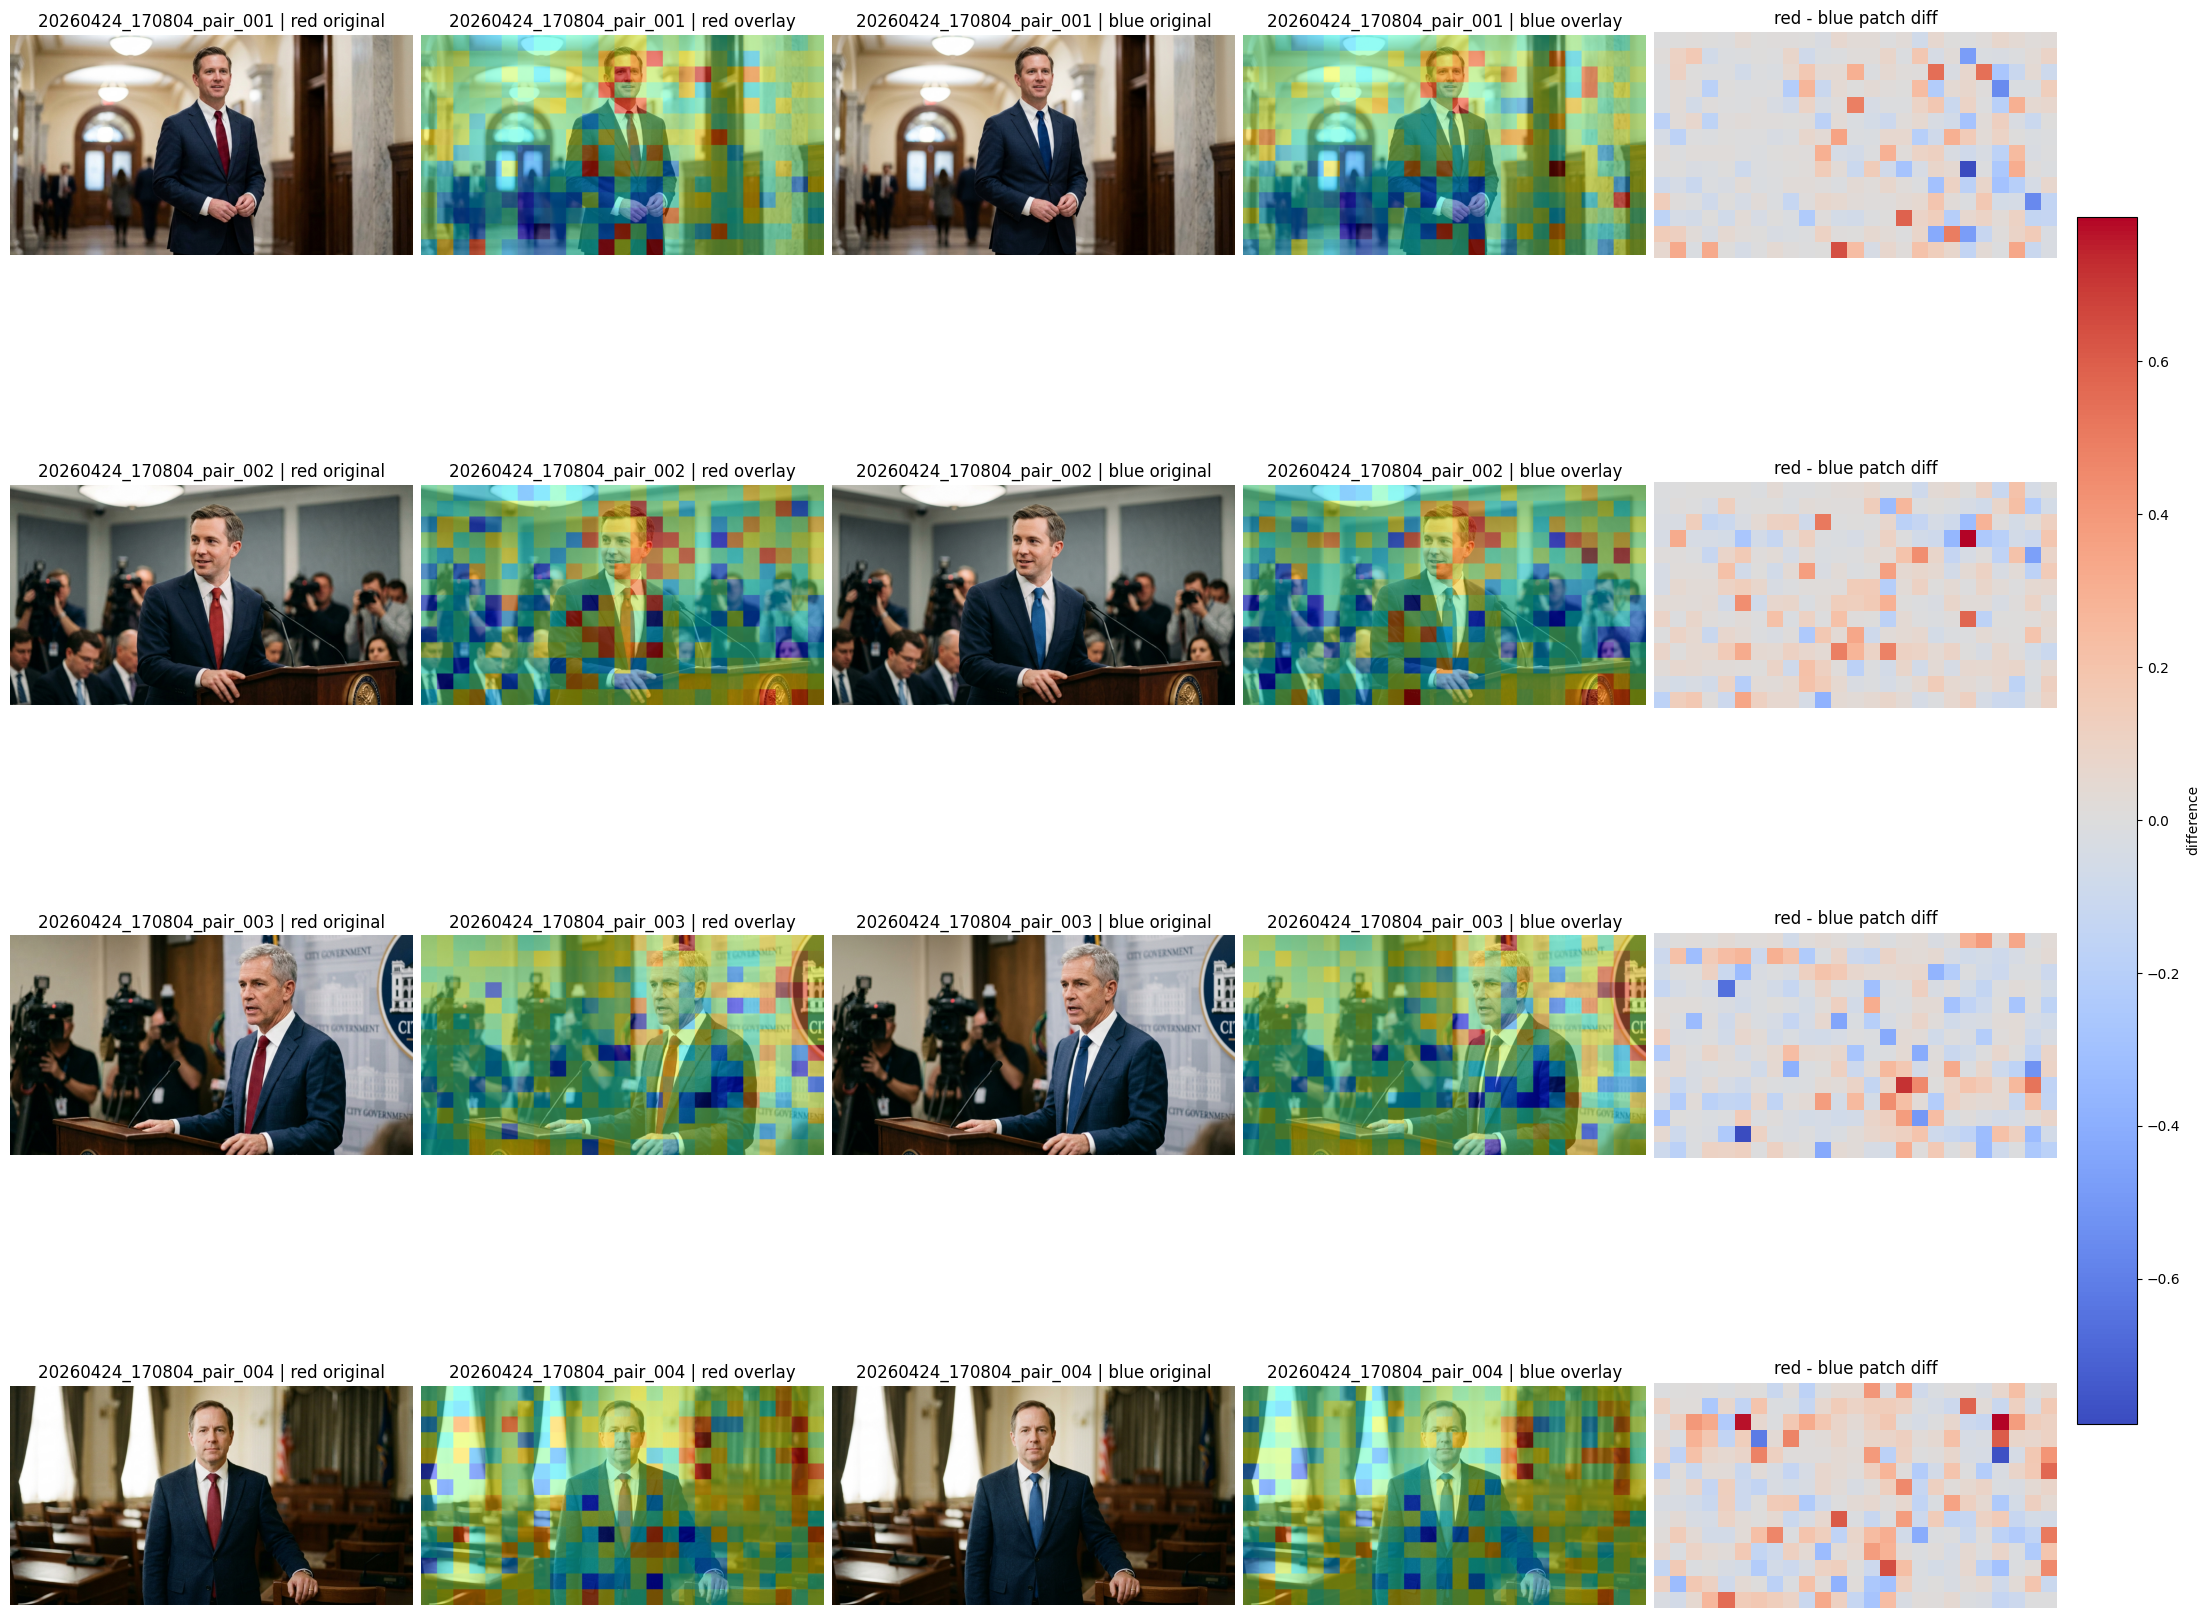

In [2]:
# Heatmaps for matched red/blue pairs (twitter_images-style overlays on original images).
from PIL import Image

def overlay_heatmap_on_image(img_pil, heatmap_hw, alpha=0.45, cmap="jet", vmin=None, vmax=None):
    img = np.asarray(img_pil.convert("RGB")).astype(np.float32) / 255.0
    h_img, w_img = img.shape[:2]

    hm = heatmap_hw.astype(np.float32)
    if vmin is None:
        vmin = float(np.nanmin(hm))
    if vmax is None:
        vmax = float(np.nanmax(hm))
    denom = (vmax - vmin) if (vmax - vmin) > 1e-8 else 1.0
    hm01 = np.clip((hm - vmin) / denom, 0.0, 1.0)

    hm_up = np.array(
        Image.fromarray((hm01 * 255).astype(np.uint8)).resize((w_img, h_img), resample=Image.Resampling.NEAREST)
    ) / 255.0

    cm = plt.get_cmap(cmap)
    hm_rgb = cm(hm_up)[..., :3]
    out = (1 - alpha) * img + alpha * hm_rgb
    return np.clip(out, 0.0, 1.0)

pair_counts = meta.groupby(["pair_key", "group"]).size().unstack(fill_value=0)
valid_pairs = pair_counts[(pair_counts.get("red", 0) > 0) & (pair_counts.get("blue", 0) > 0)].index.tolist()

if not valid_pairs:
    raise RuntimeError("No matched red/blue pairs found.")

n_show = min(4, len(valid_pairs))
show_pairs = valid_pairs[:n_show]

fig, axes = plt.subplots(n_show, 5, figsize=(22, 4.5 * n_show), constrained_layout=True)
if n_show == 1:
    axes = np.array([axes])

for row, key in enumerate(show_pairs):
    red_idx = int(meta[(meta["pair_key"] == key) & (meta["group"] == "red")].index[0])
    blue_idx = int(meta[(meta["pair_key"] == key) & (meta["group"] == "blue")].index[0])

    red_grid = image_score_grid(red_idx)
    blue_grid = image_score_grid(blue_idx)

    # If patch grids differ slightly, crop to shared shape before taking difference.
    h = min(red_grid.shape[0], blue_grid.shape[0])
    w = min(red_grid.shape[1], blue_grid.shape[1])
    red_common = red_grid[:h, :w]
    blue_common = blue_grid[:h, :w]
    diff = red_common - blue_common

    red_img = Image.open(meta.loc[red_idx, "image_path"]).convert("RGB")
    blue_img = Image.open(meta.loc[blue_idx, "image_path"]).convert("RGB")

    vmin = float(min(red_common.min(), blue_common.min()))
    vmax = float(max(red_common.max(), blue_common.max()))
    dmax = float(np.max(np.abs(diff)))

    red_overlay = overlay_heatmap_on_image(red_img, red_common, alpha=0.45, cmap="jet", vmin=vmin, vmax=vmax)
    blue_overlay = overlay_heatmap_on_image(blue_img, blue_common, alpha=0.45, cmap="jet", vmin=vmin, vmax=vmax)

    axes[row, 0].imshow(red_img)
    axes[row, 0].set_title(f"{key} | red original")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(red_overlay)
    axes[row, 1].set_title(f"{key} | red overlay")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(blue_img)
    axes[row, 2].set_title(f"{key} | blue original")
    axes[row, 2].axis("off")

    axes[row, 3].imshow(blue_overlay)
    axes[row, 3].set_title(f"{key} | blue overlay")
    axes[row, 3].axis("off")

    im_diff = axes[row, 4].imshow(diff, cmap="coolwarm", vmin=-dmax, vmax=dmax)
    axes[row, 4].set_title("red - blue patch diff")
    axes[row, 4].axis("off")

cbar = fig.colorbar(im_diff, ax=axes[:, 4].ravel().tolist(), shrink=0.85)
cbar.set_label("difference")
plt.show()

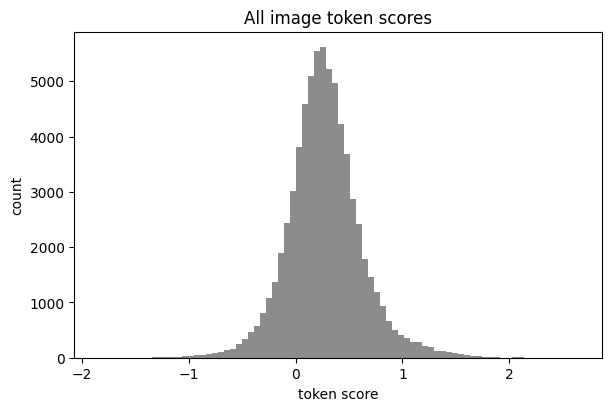

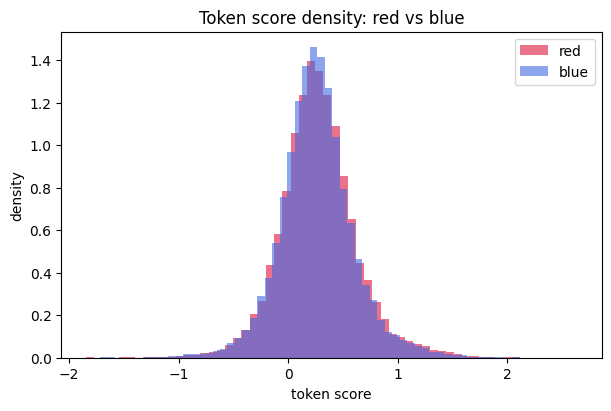

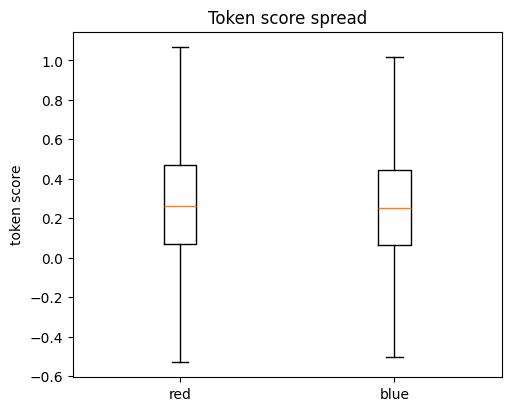

Red tokens:  n=35,000, mean=0.2780, std=0.3542
Blue tokens: n=35,000, mean=0.2636, std=0.3431
Mean delta (red-blue): 0.0143


In [3]:
# Distribution plots: all token scores + red/blue token-score distributions.
red_indices = meta.index[meta["group"] == "red"].tolist()
blue_indices = meta.index[meta["group"] == "blue"].tolist()

red_tokens = np.concatenate([image_score_vector(i) for i in red_indices]) if red_indices else np.array([])
blue_tokens = np.concatenate([image_score_vector(i) for i in blue_indices]) if blue_indices else np.array([])
all_tokens = np.concatenate([red_tokens, blue_tokens]) if len(red_tokens) and len(blue_tokens) else scores

fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
ax.hist(all_tokens, bins=80, alpha=0.9, color="gray")
ax.set_title("All image token scores")
ax.set_xlabel("token score")
ax.set_ylabel("count")
plt.show()

fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
ax.hist(red_tokens, bins=60, alpha=0.6, label="red", color="crimson", density=True)
ax.hist(blue_tokens, bins=60, alpha=0.6, label="blue", color="royalblue", density=True)
ax.set_title("Token score density: red vs blue")
ax.set_xlabel("token score")
ax.set_ylabel("density")
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(5, 4), constrained_layout=True)
ax.boxplot([red_tokens, blue_tokens], tick_labels=["red", "blue"], showfliers=False)
ax.set_title("Token score spread")
ax.set_ylabel("token score")
plt.show()

print(f"Red tokens:  n={len(red_tokens):,}, mean={red_tokens.mean():.4f}, std={red_tokens.std():.4f}")
print(f"Blue tokens: n={len(blue_tokens):,}, mean={blue_tokens.mean():.4f}, std={blue_tokens.std():.4f}")
print(f"Mean delta (red-blue): {red_tokens.mean() - blue_tokens.mean():.4f}")

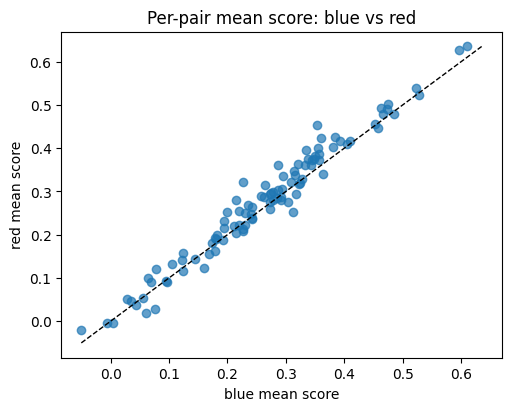

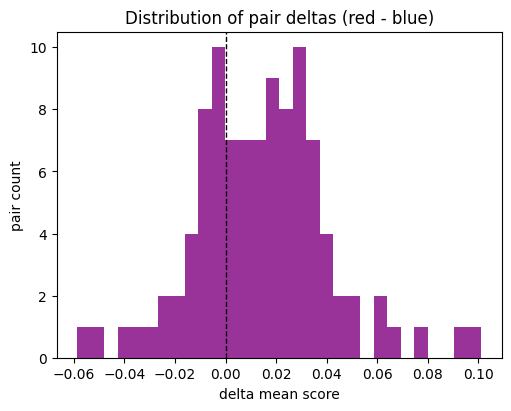

Paired samples: 100
Mean(pair red-blue): 0.0143
Median(pair red-blue): 0.0155
Share with red > blue: 0.690


In [4]:
# Pairwise group difference analysis.
paired = (
    meta[meta["group"].isin(["red", "blue"])][["pair_key", "group", "mean_score"]]
    .pivot_table(index="pair_key", columns="group", values="mean_score", aggfunc="first")
    .dropna()
)
paired["delta_red_minus_blue"] = paired["red"] - paired["blue"]

fig, ax = plt.subplots(figsize=(5, 4), constrained_layout=True)
ax.scatter(paired["blue"], paired["red"], alpha=0.7)
mn = float(min(paired["blue"].min(), paired["red"].min()))
mx = float(max(paired["blue"].max(), paired["red"].max()))
ax.plot([mn, mx], [mn, mx], "k--", linewidth=1)
ax.set_title("Per-pair mean score: blue vs red")
ax.set_xlabel("blue mean score")
ax.set_ylabel("red mean score")
plt.show()

fig, ax = plt.subplots(figsize=(5, 4), constrained_layout=True)
ax.hist(paired["delta_red_minus_blue"], bins=30, color="purple", alpha=0.8)
ax.axvline(0.0, color="black", linestyle="--", linewidth=1)
ax.set_title("Distribution of pair deltas (red - blue)")
ax.set_xlabel("delta mean score")
ax.set_ylabel("pair count")
plt.show()

delta = paired["delta_red_minus_blue"].values
print(f"Paired samples: {len(paired)}")
print(f"Mean(pair red-blue): {delta.mean():.4f}")
print(f"Median(pair red-blue): {np.median(delta):.4f}")
print(f"Share with red > blue: {(delta > 0).mean():.3f}")

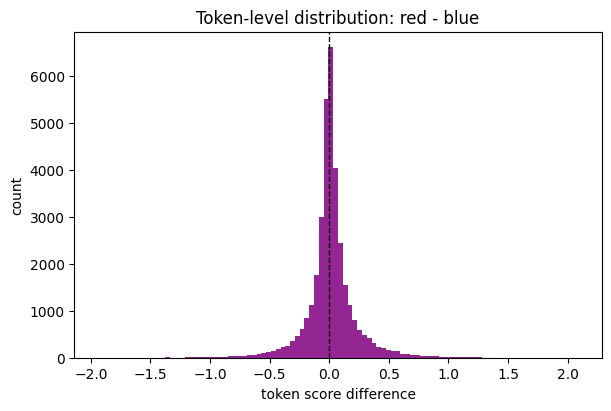

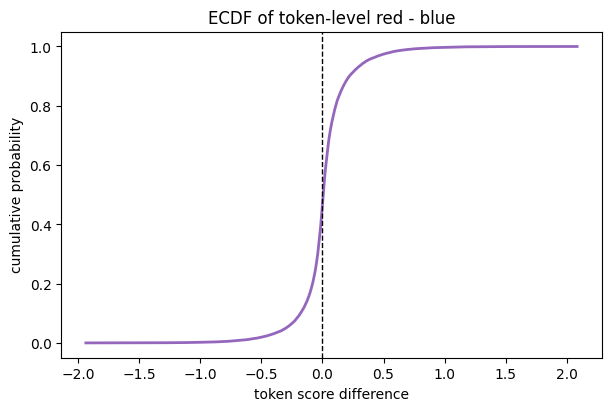

Token differences n=35,000
Mean(red-blue)=0.0143
Median(red-blue)=0.0064
Std(red-blue)=0.2152
P(red-blue > 0)=0.534


In [5]:
# Distribution of red-blue at the token level across all matched pairs.
pair_counts = meta.groupby(["pair_key", "group"]).size().unstack(fill_value=0)
valid_pairs = pair_counts[(pair_counts.get("red", 0) > 0) & (pair_counts.get("blue", 0) > 0)].index.tolist()

all_token_diffs = []
for key in valid_pairs:
    red_idx = int(meta[(meta["pair_key"] == key) & (meta["group"] == "red")].index[0])
    blue_idx = int(meta[(meta["pair_key"] == key) & (meta["group"] == "blue")].index[0])

    red_vec = image_score_vector(red_idx)
    blue_vec = image_score_vector(blue_idx)

    # Align by shared token count in case a pair has slight patch-count mismatch.
    n = min(len(red_vec), len(blue_vec))
    all_token_diffs.append(red_vec[:n] - blue_vec[:n])

token_diff = np.concatenate(all_token_diffs) if all_token_diffs else np.array([], dtype=np.float32)
if token_diff.size == 0:
    raise RuntimeError("No token-level red-blue differences available.")

fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
ax.hist(token_diff, bins=100, color="purple", alpha=0.85)
ax.axvline(0.0, color="black", linestyle="--", linewidth=1)
ax.set_title("Token-level distribution: red - blue")
ax.set_xlabel("token score difference")
ax.set_ylabel("count")
plt.show()

sorted_diff = np.sort(token_diff)
ecdf_y = np.arange(1, len(sorted_diff) + 1) / len(sorted_diff)
fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
ax.plot(sorted_diff, ecdf_y, color="tab:purple", linewidth=2)
ax.axvline(0.0, color="black", linestyle="--", linewidth=1)
ax.set_title("ECDF of token-level red - blue")
ax.set_xlabel("token score difference")
ax.set_ylabel("cumulative probability")
plt.show()

print(f"Token differences n={len(token_diff):,}")
print(f"Mean(red-blue)={token_diff.mean():.4f}")
print(f"Median(red-blue)={np.median(token_diff):.4f}")
print(f"Std(red-blue)={token_diff.std():.4f}")
print(f"P(red-blue > 0)={(token_diff > 0).mean():.3f}")

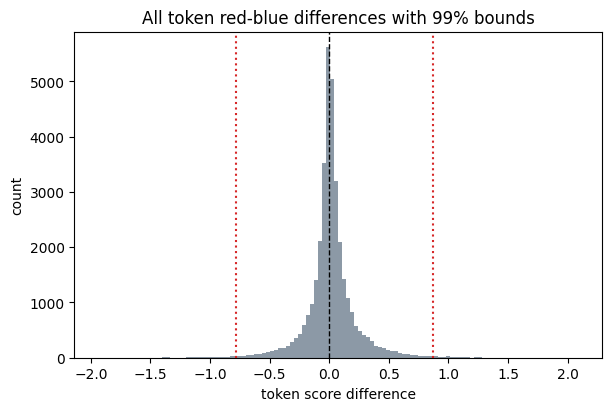

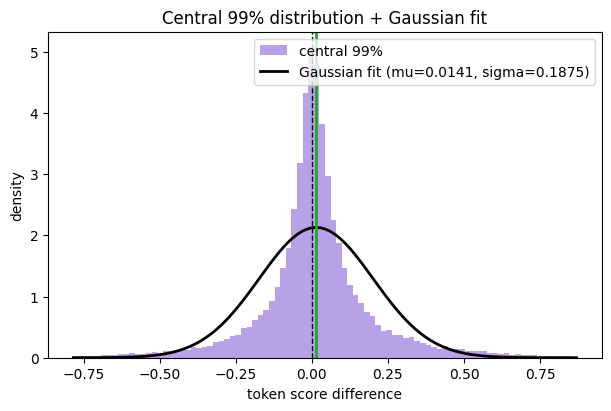

All tokens: n=35,000, mean=0.0143, std=0.2152
Central 99%: n=34,650, bounds=[-0.7842, 0.8700], mean=0.0141, std=0.1875


In [6]:
# Central 99% view + Gaussian fit for token-level red-blue differences.
if "token_diff" not in globals() or token_diff.size == 0:
    pair_counts = meta.groupby(["pair_key", "group"]).size().unstack(fill_value=0)
    valid_pairs = pair_counts[(pair_counts.get("red", 0) > 0) & (pair_counts.get("blue", 0) > 0)].index.tolist()
    diffs = []
    for key in valid_pairs:
        red_idx = int(meta[(meta["pair_key"] == key) & (meta["group"] == "red")].index[0])
        blue_idx = int(meta[(meta["pair_key"] == key) & (meta["group"] == "blue")].index[0])
        red_vec = image_score_vector(red_idx)
        blue_vec = image_score_vector(blue_idx)
        n = min(len(red_vec), len(blue_vec))
        diffs.append(red_vec[:n] - blue_vec[:n])
    token_diff = np.concatenate(diffs) if diffs else np.array([], dtype=np.float32)

if token_diff.size == 0:
    raise RuntimeError("No token-level red-blue differences available.")

lo, hi = np.quantile(token_diff, [0.005, 0.995])
core = token_diff[(token_diff >= lo) & (token_diff <= hi)]

mu = float(core.mean())
sigma = float(core.std(ddof=0))
if sigma < 1e-8:
    sigma = 1e-8

x = np.linspace(core.min(), core.max(), 500)
normal_pdf = (1.0 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
ax.hist(token_diff, bins=120, color="slategray", alpha=0.8)
ax.axvline(0.0, color="black", linestyle="--", linewidth=1)
ax.axvline(lo, color="tab:red", linestyle=":", linewidth=1.5)
ax.axvline(hi, color="tab:red", linestyle=":", linewidth=1.5)
ax.set_title("All token red-blue differences with 99% bounds")
ax.set_xlabel("token score difference")
ax.set_ylabel("count")
plt.show()

fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
ax.hist(core, bins=90, density=True, color="mediumpurple", alpha=0.65, label="central 99%")
ax.plot(x, normal_pdf, color="black", linewidth=2, label=f"Gaussian fit (mu={mu:.4f}, sigma={sigma:.4f})")
ax.axvline(0.0, color="black", linestyle="--", linewidth=1)
ax.axvline(mu, color="tab:green", linestyle="-", linewidth=2)
ax.set_title("Central 99% distribution + Gaussian fit")
ax.set_xlabel("token score difference")
ax.set_ylabel("density")
ax.legend()
plt.show()

print(f"All tokens: n={len(token_diff):,}, mean={token_diff.mean():.4f}, std={token_diff.std():.4f}")
print(f"Central 99%: n={len(core):,}, bounds=[{lo:.4f}, {hi:.4f}], mean={core.mean():.4f}, std={core.std():.4f}")

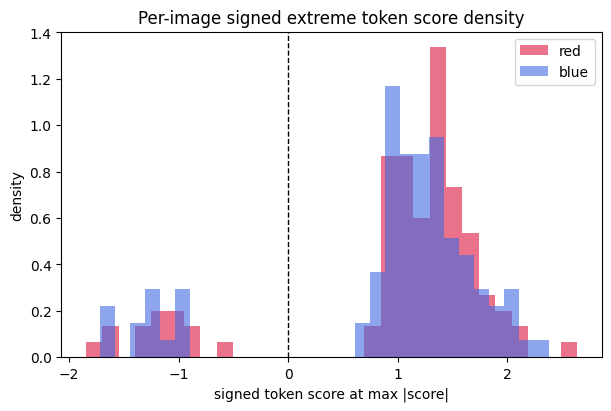

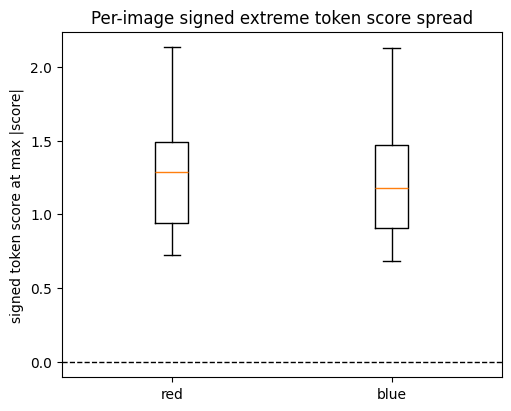

 index group  count     mean   median      std       min      max
     0  blue    100 0.944841 1.178223 0.957925 -1.715759 2.386230
     1   red    100 0.992851 1.284363 0.948227 -1.847778 2.641113


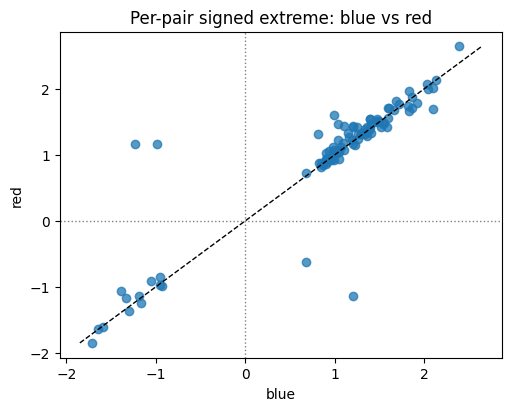

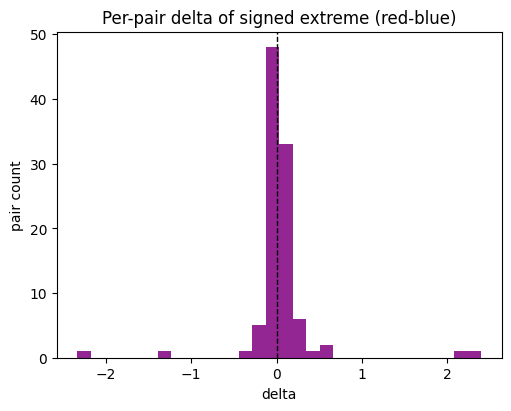

In [7]:
# Signed extreme-token analysis per image: score at argmax(|token score|).
def signed_extreme_token_score(vec: np.ndarray) -> float:
    if vec.size == 0:
        return np.nan
    idx = int(np.argmax(np.abs(vec)))
    return float(vec[idx])

meta_extreme = meta.copy()
meta_extreme["signed_extreme_token_score"] = [signed_extreme_token_score(image_score_vector(i)) for i in range(len(meta_extreme))]

df_groups = meta_extreme[meta_extreme["group"].isin(["red", "blue"])].copy()
if df_groups.empty:
    raise RuntimeError("No red/blue rows found for signed-extreme analysis.")

red_extreme = df_groups.loc[df_groups["group"] == "red", "signed_extreme_token_score"].to_numpy()
blue_extreme = df_groups.loc[df_groups["group"] == "blue", "signed_extreme_token_score"].to_numpy()

fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
ax.hist(red_extreme, bins=30, alpha=0.6, color="crimson", label="red", density=True)
ax.hist(blue_extreme, bins=30, alpha=0.6, color="royalblue", label="blue", density=True)
ax.axvline(0.0, color="black", linestyle="--", linewidth=1)
ax.set_title("Per-image signed extreme token score density")
ax.set_xlabel("signed token score at max |score|")
ax.set_ylabel("density")
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(5, 4), constrained_layout=True)
ax.boxplot([red_extreme, blue_extreme], tick_labels=["red", "blue"], showfliers=False)
ax.axhline(0.0, color="black", linestyle="--", linewidth=1)
ax.set_title("Per-image signed extreme token score spread")
ax.set_ylabel("signed token score at max |score|")
plt.show()

summary = (
    df_groups.groupby("group", as_index=False)["signed_extreme_token_score"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .reset_index()
)
print(summary.to_string(index=False))

paired_extreme = (
    df_groups[["pair_key", "group", "signed_extreme_token_score"]]
    .pivot_table(index="pair_key", columns="group", values="signed_extreme_token_score", aggfunc="first")
    .dropna()
)
paired_extreme["delta_red_minus_blue"] = paired_extreme["red"] - paired_extreme["blue"]

mn = float(min(paired_extreme["blue"].min(), paired_extreme["red"].min()))
mx = float(max(paired_extreme["blue"].max(), paired_extreme["red"].max()))
fig, ax = plt.subplots(figsize=(5, 4), constrained_layout=True)
ax.scatter(paired_extreme["blue"], paired_extreme["red"], alpha=0.75)
ax.plot([mn, mx], [mn, mx], "k--", linewidth=1)
ax.axhline(0.0, color="gray", linestyle=":", linewidth=1)
ax.axvline(0.0, color="gray", linestyle=":", linewidth=1)
ax.set_title("Per-pair signed extreme: blue vs red")
ax.set_xlabel("blue")
ax.set_ylabel("red")
plt.show()

fig, ax = plt.subplots(figsize=(5, 4), constrained_layout=True)
ax.hist(paired_extreme["delta_red_minus_blue"], bins=30, color="purple", alpha=0.85)
ax.axvline(0.0, color="black", linestyle="--", linewidth=1)
ax.set_title("Per-pair delta of signed extreme (red-blue)")
ax.set_xlabel("delta")
ax.set_ylabel("pair count")
plt.show()

In [8]:
# Significance tests for red vs blue: mean-score and signed max-extreme scenarios.
from scipy import stats as scipy_stats

results = []

# -----------------------------
# A) Mean-score scenario
# -----------------------------
# A1) Token-level (treats tokens as independent; optimistic p-values)
a_tok = red_tokens
b_tok = blue_tokens

t_stat_tok, p_t_tok = scipy_stats.ttest_ind(a_tok, b_tok, equal_var=False)
u_stat_tok, p_u_tok = scipy_stats.mannwhitneyu(a_tok, b_tok, alternative="two-sided")

mean_diff_tok = float(a_tok.mean() - b_tok.mean())
pooled_sd_tok = float(np.sqrt(((len(a_tok) - 1) * a_tok.var(ddof=1) + (len(b_tok) - 1) * b_tok.var(ddof=1)) / (len(a_tok) + len(b_tok) - 2)))
cohens_d_tok = mean_diff_tok / pooled_sd_tok if pooled_sd_tok > 0 else np.nan

results.extend([
    {"scenario": "mean_score", "analysis": "token_level_unpaired", "test": "welch_t", "stat": float(t_stat_tok), "pvalue": float(p_t_tok), "effect": mean_diff_tok, "effect_name": "red-blue mean diff"},
    {"scenario": "mean_score", "analysis": "token_level_unpaired", "test": "mannwhitney_u", "stat": float(u_stat_tok), "pvalue": float(p_u_tok), "effect": cohens_d_tok, "effect_name": "cohens_d"},
])

# A2) Pair-level mean differences (recommended for matched pairs)
if "paired" not in globals() or "delta_red_minus_blue" not in paired.columns:
    paired = (
        meta[meta["group"].isin(["red", "blue"])][["pair_key", "group", "mean_score"]]
        .pivot_table(index="pair_key", columns="group", values="mean_score", aggfunc="first")
        .dropna()
    )
    paired["delta_red_minus_blue"] = paired["red"] - paired["blue"]

delta_mean = paired["delta_red_minus_blue"].to_numpy()

t_stat_pair_mean, p_t_pair_mean = scipy_stats.ttest_1samp(delta_mean, popmean=0.0)
try:
    w_stat_pair_mean, p_w_pair_mean = scipy_stats.wilcoxon(delta_mean)
except ValueError:
    w_stat_pair_mean, p_w_pair_mean = np.nan, np.nan

n_pos_mean = int(np.sum(delta_mean > 0))
n_nonzero_mean = int(np.sum(delta_mean != 0))
if n_nonzero_mean > 0:
    p_sign_mean = scipy_stats.binomtest(n_pos_mean, n=n_nonzero_mean, p=0.5, alternative="two-sided").pvalue
else:
    p_sign_mean = np.nan

dz_mean = float(delta_mean.mean() / delta_mean.std(ddof=1)) if delta_mean.std(ddof=1) > 0 else np.nan

results.extend([
    {"scenario": "mean_score", "analysis": "pair_level", "test": "paired_t_vs_zero", "stat": float(t_stat_pair_mean), "pvalue": float(p_t_pair_mean), "effect": float(delta_mean.mean()), "effect_name": "mean_delta"},
    {"scenario": "mean_score", "analysis": "pair_level", "test": "wilcoxon_signed_rank", "stat": float(w_stat_pair_mean) if np.isfinite(w_stat_pair_mean) else np.nan, "pvalue": float(p_w_pair_mean) if np.isfinite(p_w_pair_mean) else np.nan, "effect": dz_mean, "effect_name": "cohens_dz"},
    {"scenario": "mean_score", "analysis": "pair_level", "test": "sign_test", "stat": float(n_pos_mean), "pvalue": float(p_sign_mean) if np.isfinite(p_sign_mean) else np.nan, "effect": float((delta_mean > 0).mean()), "effect_name": "share_positive"},
])

# -----------------------------
# B) Signed max-extreme scenario
# -----------------------------
if "paired_extreme" not in globals() or "delta_red_minus_blue" not in paired_extreme.columns:
    meta_extreme = meta.copy()
    meta_extreme["signed_extreme_token_score"] = [
        float(image_score_vector(i)[int(np.argmax(np.abs(image_score_vector(i))))])
        for i in range(len(meta_extreme))
    ]
    df_groups = meta_extreme[meta_extreme["group"].isin(["red", "blue"])].copy()
    paired_extreme = (
        df_groups[["pair_key", "group", "signed_extreme_token_score"]]
        .pivot_table(index="pair_key", columns="group", values="signed_extreme_token_score", aggfunc="first")
        .dropna()
    )
    paired_extreme["delta_red_minus_blue"] = paired_extreme["red"] - paired_extreme["blue"]

delta_extreme = paired_extreme["delta_red_minus_blue"].to_numpy()

# Pair-level tests for signed extreme metric
t_stat_pair_ext, p_t_pair_ext = scipy_stats.ttest_1samp(delta_extreme, popmean=0.0)
try:
    w_stat_pair_ext, p_w_pair_ext = scipy_stats.wilcoxon(delta_extreme)
except ValueError:
    w_stat_pair_ext, p_w_pair_ext = np.nan, np.nan

n_pos_ext = int(np.sum(delta_extreme > 0))
n_nonzero_ext = int(np.sum(delta_extreme != 0))
if n_nonzero_ext > 0:
    p_sign_ext = scipy_stats.binomtest(n_pos_ext, n=n_nonzero_ext, p=0.5, alternative="two-sided").pvalue
else:
    p_sign_ext = np.nan

dz_ext = float(delta_extreme.mean() / delta_extreme.std(ddof=1)) if delta_extreme.std(ddof=1) > 0 else np.nan

results.extend([
    {"scenario": "signed_max_extreme", "analysis": "pair_level", "test": "paired_t_vs_zero", "stat": float(t_stat_pair_ext), "pvalue": float(p_t_pair_ext), "effect": float(delta_extreme.mean()), "effect_name": "mean_delta"},
    {"scenario": "signed_max_extreme", "analysis": "pair_level", "test": "wilcoxon_signed_rank", "stat": float(w_stat_pair_ext) if np.isfinite(w_stat_pair_ext) else np.nan, "pvalue": float(p_w_pair_ext) if np.isfinite(p_w_pair_ext) else np.nan, "effect": dz_ext, "effect_name": "cohens_dz"},
    {"scenario": "signed_max_extreme", "analysis": "pair_level", "test": "sign_test", "stat": float(n_pos_ext), "pvalue": float(p_sign_ext) if np.isfinite(p_sign_ext) else np.nan, "effect": float((delta_extreme > 0).mean()), "effect_name": "share_positive"},
])

results_df = pd.DataFrame(results)

display(results_df)

print("\nRecommended interpretation: use pair_level rows (matched red/blue image pairs).")
print("Token-level unpaired rows are included for reference and usually overstate significance due to token dependence.")

,scenario,analysis,test,stat,pvalue,effect,effect_name
0,mean_score,token_level_unpaired,welch_t,5.429385e+00,5.673626e-08,0.014312,red-blue mean diff
1,mean_score,token_level_unpaired,mannwhitney_u,6.269713e+08,6.180564e-08,0.041042,cohens_d
2,mean_score,pair_level,paired_t_vs_zero,5.337695e+00,5.987768e-07,0.014312,mean_delta
3,mean_score,pair_level,wilcoxon_signed_rank,1.084000e+03,7.246951e-07,0.533770,cohens_dz
4,mean_score,pair_level,sign_test,6.900000e+01,1.831432e-04,0.690000,share_positive
5,signed_max_extreme,pair_level,paired_t_vs_zero,1.088320e+00,2.790963e-01,0.048011,mean_delta
6,signed_max_extreme,pair_level,wilcoxon_signed_rank,1.798000e+03,1.243111e-02,0.108832,cohens_dz
7,signed_max_extreme,pair_level,sign_test,6.100000e+01,3.520020e-02,0.610000,share_positive



Recommended interpretation: use pair_level rows (matched red/blue image pairs).
Token-level unpaired rows are included for reference and usually overstate significance due to token dependence.


In [9]:
# Load all-token scores and extract last token position for each image.
ALL_TOKENS_PATH = RESULTS_DIR / "news_images_all_tokens.pt"

if not ALL_TOKENS_PATH.exists():
    print(f"Warning: All-tokens file not found at {ALL_TOKENS_PATH}")
    print("Skipping last-token analysis. Run scoring script with updated version to generate this file.")
else:
    all_tokens_payload = torch.load(ALL_TOKENS_PATH, map_location="cpu")
    all_token_scores = all_tokens_payload["all_token_scores"]  # List of tensors
    seq_lengths = all_tokens_payload["seq_lengths"].numpy()
    
    # Extract last token score for each image
    last_token_scores = []
    for i, score_tensor in enumerate(all_token_scores):
        if len(score_tensor) > 0:
            last_score = float(score_tensor[-1])  # Last token in sequence
        else:
            last_score = np.nan
        last_token_scores.append(last_score)
    
    last_token_scores = np.array(last_token_scores, dtype=np.float32)
    
    # Add to metadata
    meta["last_token_score"] = last_token_scores
    meta["seq_length"] = seq_lengths
    
    print(f"Loaded all-token scores for {len(all_token_scores)} images")
    print(f"Last token scores: min={np.nanmin(last_token_scores):.4f}, max={np.nanmax(last_token_scores):.4f}, mean={np.nanmean(last_token_scores):.4f}")

Loaded all-token scores for 200 images
Last token scores: min=-0.0167, max=0.1938, mean=0.0857


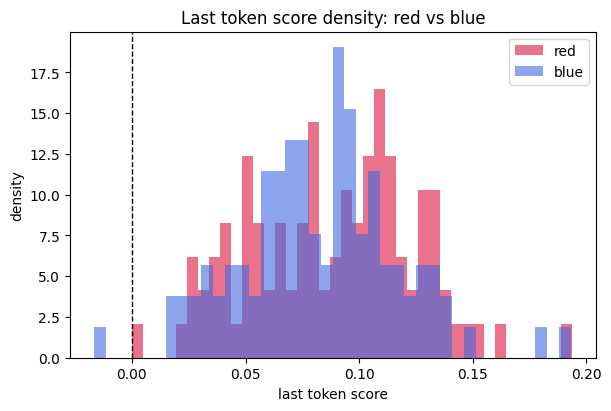

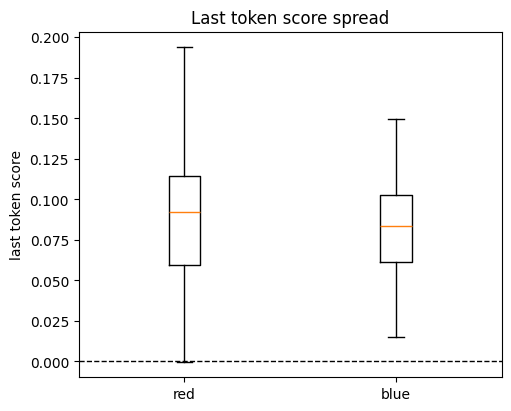

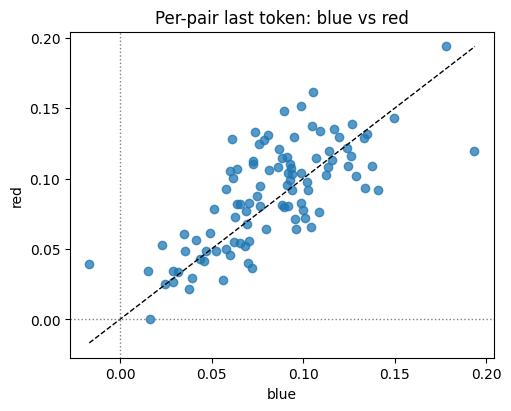

Red last tokens:  n=100, mean=0.0887, std=0.0365, median=0.0924
Blue last tokens: n=100, mean=0.0827, std=0.0349, median=0.0836
Mean delta (red-blue): 0.0059


In [10]:
# Distribution of last token scores: red vs blue.
if "last_token_scores" not in locals():
    print("Last token scores not loaded. Run previous cell first.")
else:
    red_last = meta.loc[meta["group"] == "red", "last_token_score"].dropna().to_numpy()
    blue_last = meta.loc[meta["group"] == "blue", "last_token_score"].dropna().to_numpy()
    
    fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
    ax.hist(red_last, bins=40, alpha=0.6, label="red", color="crimson", density=True)
    ax.hist(blue_last, bins=40, alpha=0.6, label="blue", color="royalblue", density=True)
    ax.axvline(0.0, color="black", linestyle="--", linewidth=1)
    ax.set_title("Last token score density: red vs blue")
    ax.set_xlabel("last token score")
    ax.set_ylabel("density")
    ax.legend()
    plt.show()
    
    fig, ax = plt.subplots(figsize=(5, 4), constrained_layout=True)
    ax.boxplot([red_last, blue_last], tick_labels=["red", "blue"], showfliers=False)
    ax.axhline(0.0, color="black", linestyle="--", linewidth=1)
    ax.set_title("Last token score spread")
    ax.set_ylabel("last token score")
    plt.show()
    
    # Scatter: red vs blue for pairs
    paired_last = (
        meta.dropna(subset=["last_token_score"])[["pair_key", "group", "last_token_score"]]
        .pivot_table(index="pair_key", columns="group", values="last_token_score", aggfunc="first")
        .dropna()
    )
    
    if len(paired_last) > 0:
        fig, ax = plt.subplots(figsize=(5, 4), constrained_layout=True)
        ax.scatter(paired_last["blue"], paired_last["red"], alpha=0.75)
        mn = float(min(paired_last["blue"].min(), paired_last["red"].min()))
        mx = float(max(paired_last["blue"].max(), paired_last["red"].max()))
        ax.plot([mn, mx], [mn, mx], "k--", linewidth=1)
        ax.axhline(0.0, color="gray", linestyle=":", linewidth=1)
        ax.axvline(0.0, color="gray", linestyle=":", linewidth=1)
        ax.set_title("Per-pair last token: blue vs red")
        ax.set_xlabel("blue")
        ax.set_ylabel("red")
        plt.show()
    
    print(f"Red last tokens:  n={len(red_last)}, mean={red_last.mean():.4f}, std={red_last.std():.4f}, median={np.median(red_last):.4f}")
    print(f"Blue last tokens: n={len(blue_last)}, mean={blue_last.mean():.4f}, std={blue_last.std():.4f}, median={np.median(blue_last):.4f}")
    print(f"Mean delta (red-blue): {red_last.mean() - blue_last.mean():.4f}")

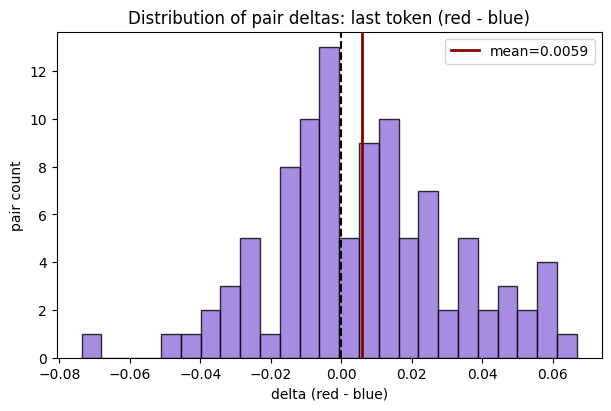

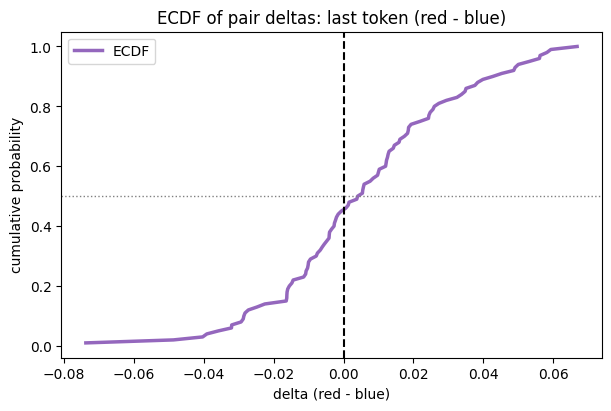

Paired last token analysis (n=100 pairs):
  Mean delta (red-blue): 0.0059
  Median delta: 0.0047
  Std: 0.0263
  Share with red > blue: 0.550
  Min: -0.0737, Max: 0.0668


In [11]:
# Paired analysis: last token score difference (red - blue).
if "paired_last" not in locals():
    paired_last = (
        meta.dropna(subset=["last_token_score"])[["pair_key", "group", "last_token_score"]]
        .pivot_table(index="pair_key", columns="group", values="last_token_score", aggfunc="first")
        .dropna()
    )

if len(paired_last) == 0:
    print("No matched red/blue pairs with last token scores.")
else:
    paired_last["delta_red_minus_blue"] = paired_last["red"] - paired_last["blue"]
    delta_last = paired_last["delta_red_minus_blue"].to_numpy()
    
    fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
    ax.hist(delta_last, bins=25, color="mediumpurple", alpha=0.8, edgecolor="black")
    ax.axvline(0.0, color="black", linestyle="--", linewidth=1.5)
    ax.axvline(delta_last.mean(), color="darkred", linestyle="-", linewidth=2, label=f"mean={delta_last.mean():.4f}")
    ax.set_title("Distribution of pair deltas: last token (red - blue)")
    ax.set_xlabel("delta (red - blue)")
    ax.set_ylabel("pair count")
    ax.legend()
    plt.show()
    
    sorted_delta = np.sort(delta_last)
    ecdf_y = np.arange(1, len(sorted_delta) + 1) / len(sorted_delta)
    fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
    ax.plot(sorted_delta, ecdf_y, color="tab:purple", linewidth=2.5, label="ECDF")
    ax.axvline(0.0, color="black", linestyle="--", linewidth=1.5)
    ax.axhline(0.5, color="gray", linestyle=":", linewidth=1)
    ax.set_title("ECDF of pair deltas: last token (red - blue)")
    ax.set_xlabel("delta (red - blue)")
    ax.set_ylabel("cumulative probability")
    ax.legend()
    plt.show()
    
    print(f"Paired last token analysis (n={len(paired_last)} pairs):")
    print(f"  Mean delta (red-blue): {delta_last.mean():.4f}")
    print(f"  Median delta: {np.median(delta_last):.4f}")
    print(f"  Std: {delta_last.std():.4f}")
    print(f"  Share with red > blue: {(delta_last > 0).mean():.3f}")
    print(f"  Min: {delta_last.min():.4f}, Max: {delta_last.max():.4f}")

In [12]:
# Significance tests for last token score differences.
if "delta_last" not in locals():
    paired_last = (
        meta.dropna(subset=["last_token_score"])[["pair_key", "group", "last_token_score"]]
        .pivot_table(index="pair_key", columns="group", values="last_token_score", aggfunc="first")
        .dropna()
    )
    if len(paired_last) > 0:
        paired_last["delta_red_minus_blue"] = paired_last["red"] - paired_last["blue"]
        delta_last = paired_last["delta_red_minus_blue"].to_numpy()
    else:
        delta_last = np.array([])

if len(delta_last) == 0:
    print("No paired data for last token significance tests.")
else:
    red_last = meta.loc[meta["group"] == "red", "last_token_score"].dropna().to_numpy()
    blue_last = meta.loc[meta["group"] == "blue", "last_token_score"].dropna().to_numpy()
    
    results_last = []
    
    # ===== Token-level unpaired analysis (optimistic, treats tokens as independent)
    t_stat_tok, p_t_tok = scipy_stats.ttest_ind(red_last, blue_last, equal_var=False)
    u_stat_tok, p_u_tok = scipy_stats.mannwhitneyu(red_last, blue_last, alternative="two-sided")
    
    mean_diff_tok = float(red_last.mean() - blue_last.mean())
    pooled_sd_tok = float(np.sqrt(((len(red_last) - 1) * red_last.var(ddof=1) + (len(blue_last) - 1) * blue_last.var(ddof=1)) / (len(red_last) + len(blue_last) - 2)))
    cohens_d_tok = mean_diff_tok / pooled_sd_tok if pooled_sd_tok > 0 else np.nan
    
    results_last.extend([
        {"context": "last_token_score", "analysis": "image_level_unpaired", "test": "welch_t", "stat": float(t_stat_tok), "pvalue": float(p_t_tok), "effect": mean_diff_tok, "effect_name": "red-blue mean diff"},
        {"context": "last_token_score", "analysis": "image_level_unpaired", "test": "mannwhitney_u", "stat": float(u_stat_tok), "pvalue": float(p_u_tok), "effect": cohens_d_tok, "effect_name": "cohens_d"},
    ])
    
    # ===== Pair-level paired tests (recommended)
    t_stat_pair, p_t_pair = scipy_stats.ttest_1samp(delta_last, popmean=0.0)
    try:
        w_stat_pair, p_w_pair = scipy_stats.wilcoxon(delta_last)
    except ValueError:
        w_stat_pair, p_w_pair = np.nan, np.nan
    
    n_pos = int(np.sum(delta_last > 0))
    n_nonzero = int(np.sum(delta_last != 0))
    if n_nonzero > 0:
        p_sign = scipy_stats.binomtest(n_pos, n=n_nonzero, p=0.5, alternative="two-sided").pvalue
    else:
        p_sign = np.nan
    
    dz = float(delta_last.mean() / delta_last.std(ddof=1)) if delta_last.std(ddof=1) > 0 else np.nan
    
    results_last.extend([
        {"context": "last_token_score", "analysis": "pair_level", "test": "paired_t_vs_zero", "stat": float(t_stat_pair), "pvalue": float(p_t_pair), "effect": float(delta_last.mean()), "effect_name": "mean_delta"},
        {"context": "last_token_score", "analysis": "pair_level", "test": "wilcoxon_signed_rank", "stat": float(w_stat_pair) if np.isfinite(w_stat_pair) else np.nan, "pvalue": float(p_w_pair) if np.isfinite(p_w_pair) else np.nan, "effect": dz, "effect_name": "cohens_dz"},
        {"context": "last_token_score", "analysis": "pair_level", "test": "sign_test", "stat": float(n_pos), "pvalue": float(p_sign) if np.isfinite(p_sign) else np.nan, "effect": float((delta_last > 0).mean()), "effect_name": "share_positive"},
    ])
    
    results_last_df = pd.DataFrame(results_last)
    
    display(results_last_df)
    
    print("\nInterpretation:")
    print("  - Use pair_level rows for statistical inference (matched red/blue pairs)")
    print("  - image_level_unpaired rows are optimistic and may overstate significance")

,context,analysis,test,stat,pvalue,effect,effect_name
0,last_token_score,image_level_unpaired,welch_t,1.168803,0.243891,0.005934,red-blue mean diff
1,last_token_score,image_level_unpaired,mannwhitney_u,5564.000000,0.168558,0.165294,cohens_d
2,last_token_score,pair_level,paired_t_vs_zero,2.246479,0.026895,0.005934,mean_delta
3,last_token_score,pair_level,wilcoxon_signed_rank,1936.000000,0.042849,0.224648,cohens_dz
4,last_token_score,pair_level,sign_test,55.000000,0.368202,0.550000,share_positive



Interpretation:
  - Use pair_level rows for statistical inference (matched red/blue pairs)
  - image_level_unpaired rows are optimistic and may overstate significance
